# Exercício — Métricas de Avaliação em Machine Learning

**Disciplina:** Técnicas em Aprendizagem por Máquinas
**Tema:** Métricas de Regressão e de Classificação

Este notebook complementa a aula sobre métricas de avaliação. Ele está dividido em três partes:

1. **Parte 1 — Métricas de Regressão**, usando o dataset *Diabetes* (`sklearn.datasets`).
2. **Parte 2 — Métricas de Classificação**, usando o dataset *Breast Cancer Wisconsin* (`sklearn.datasets`).

## Configuração inicial

Importação das bibliotecas que usaremos ao longo do notebook.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report
)

# np.random.seed(42)
# plt.rcParams["figure.figsize"] = (6, 4)

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
# Parte 1 — Métricas de Regressão

**Dataset:** *Diabetes* — 442 pacientes, 10 variáveis fisiológicas padronizadas
(idade, sexo, IMC, pressão arterial média e seis medidas sanguíneas), com o objetivo
de prever um índice de progressão da doença um ano após a linha de base.

**Motivação:** Em um cenário clínico, prever a progressão da diabetes ajuda a priorizar
o acompanhamento de pacientes de maior risco. Diferentes métricas de erro contam
histórias diferentes sobre o quão "erradas" são as previsões do modelo — e essa
diferença importa quando o erro tem custo humano.


## Passo 1 — Coleta e exploração dos dados

In [50]:
diabetes = load_diabetes(as_frame=True)
df_diab = diabetes.frame

print("Formato do dataset:", df_diab.shape)
df_diab.head()


Formato do dataset: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


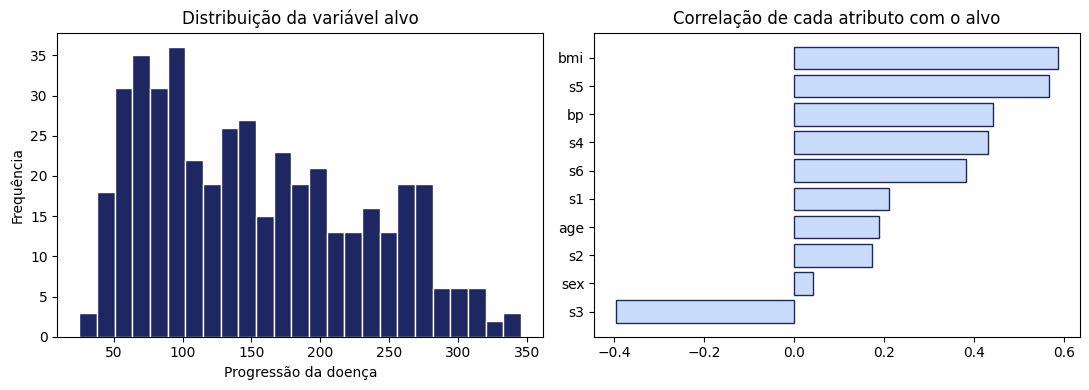

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_diab["target"], bins=25, color="#1E2761", edgecolor="white")
axes[0].set_title("Distribuição da variável alvo")
axes[0].set_xlabel("Progressão da doença")
axes[0].set_ylabel("Frequência")

corrs = df_diab.corr()["target"].drop("target").sort_values()
axes[1].barh(corrs.index, corrs.values, color="#CADCFC", edgecolor="#1E2761")
axes[1].set_title("Correlação de cada atributo com o alvo")

plt.tight_layout()
plt.show()


In [52]:
X = df_diab.drop(columns=["target"])
y = df_diab["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Treino:", X_train.shape, " | Teste:", X_test.shape)


Treino: (353, 10)  | Teste: (89, 10)


In [53]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_train, y_train)

y_pred = modelo_reg.predict(X_test)

y_pred[:5]


array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872])

In [54]:
y_test_arr = y_test.values

mae_manual = np.mean(np.abs(y_test_arr - y_pred))
mse_manual = np.mean((y_test_arr - y_pred) ** 2)
mape_manual = np.mean(np.abs((y_test_arr - y_pred) / y_test_arr)) * 100

print(f"MAE (manual):  {mae_manual:.3f}")
print(f"MSE (manual):  {mse_manual:.3f}")
print(f"MAPE (manual): {mape_manual:.2f}%")


MAE (manual):  42.794
MSE (manual):  2900.194
MAPE (manual): 37.50%


In [55]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
k = X_test.shape[1]
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"MAE:          {mae:.3f}")
print(f"MSE:          {mse:.3f}")
print(f"RMSE:         {rmse:.3f}")
print(f"R²:           {r2:.3f}")
print(f"R² Ajustado:  {r2_ajustado:.3f}")
print(f"MAPE:         {mape:.3f}%")


MAE:          42.794
MSE:          2900.194
RMSE:         53.853
R²:           0.453
R² Ajustado:  0.382
MAPE:         37.500%


---
# Parte 2 — Métricas de Classificação

**Dataset:** *Breast Cancer Wisconsin (Diagnostic)* — 569 exames, 30 atributos numéricos
extraídos de imagens digitalizadas de biópsias, com alvo binário: **maligno (0)** ou **benigno (1)**.

**Motivação:** Em diagnóstico médico, os dois tipos de erro têm custos muito diferentes.
Classificar um tumor maligno como benigno (falso negativo) pode atrasar um tratamento
essencial; classificar um tumor benigno como maligno (falso positivo) gera exames e
ansiedade desnecessários. Essa assimetria é exatamente o tipo de situação em que escolher
a métrica certa — e não só a acurácia — faz toda a diferença.


In [39]:
cancer = load_breast_cancer(as_frame=True)
df_cancer = cancer.frame

print("Formato do dataset:", df_cancer.shape)
print("\nClasses:", dict(zip(cancer.target_names, [0, 1])))
df_cancer["target"].value_counts()


Formato do dataset: (569, 31)

Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


target
1    357
0    212
Name: count, dtype: int64

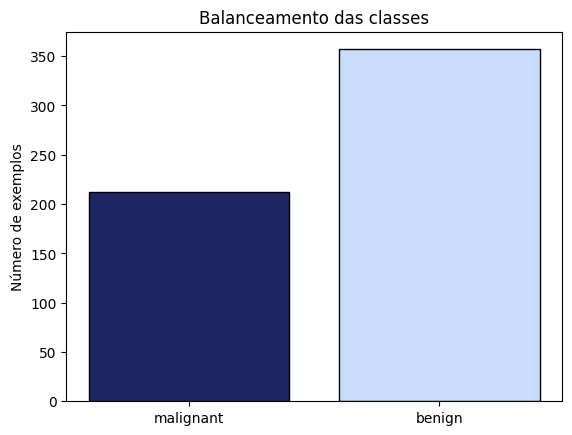

Proporção da classe majoritária: 62.7%


In [40]:
counts = df_cancer["target"].value_counts().sort_index()
labels = [cancer.target_names[i] for i in counts.index]

plt.bar(labels, counts.values, color=["#1E2761", "#CADCFC"], edgecolor="black")
plt.title("Balanceamento das classes")
plt.ylabel("Número de exemplos")
plt.show()

print(f"Proporção da classe majoritária: {counts.max() / counts.sum():.1%}")


In [41]:
X = df_cancer.drop(columns=["target"])
y = df_cancer["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train_scaled.shape, " | Teste:", X_test_scaled.shape)


Treino: (426, 30)  | Teste: (143, 30)


In [42]:
modelo_clf = LogisticRegression(max_iter=1000)
modelo_clf.fit(X_train_scaled, y_train)

y_pred = modelo_clf.predict(X_test_scaled)
y_proba = modelo_clf.predict_proba(X_test_scaled)[:, 1]

y_pred[:10], y_proba[:5]


(array([1, 0, 1, 1, 0, 0, 0, 0, 0, 1]),
 array([9.68982023e-01, 3.52018216e-04, 5.59411532e-01, 9.38945753e-01,
        1.75491868e-01]))

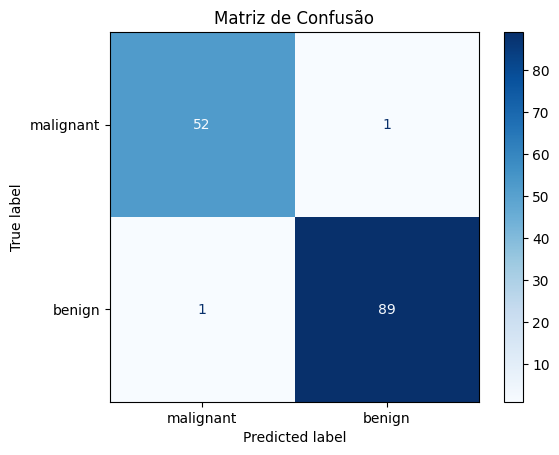

array([[52,  1],
       [ 1, 89]])

In [43]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

cm


> Convenção adotada aqui: a classe **maligno (0)** é tratada como a classe positiva de interesse
> (é a que queremos detectar), então usamos `pos_label=0` nas métricas.

In [44]:
acc = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, pos_label=0)
revocacao = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)
auc = roc_auc_score(1 - y_test, 1 - y_proba)

print(f"Acurácia:  {acc:.3f}")
print(f"Precisão:  {precisao:.3f}")
print(f"Revocação: {revocacao:.3f}")
print(f"F1:        {f1:.3f}")
print(f"AUC-ROC:   {auc:.3f}")


Acurácia:  0.986
Precisão:  0.981
Revocação: 0.981
F1:        0.981
AUC-ROC:   0.998


Agora, confira a precisão e a revocação **manualmente** a partir da matriz de confusão (`cm`), lembrando que aqui a linha/coluna 0 corresponde à classe maligno.

In [45]:
TP = cm[0, 0]
FN = cm[0, 1]
FP = cm[1, 0]
TN = cm[1, 1]

precisao_manual = TP / (TP + FP)
revocacao_manual = TP / (TP + FN)

print(f"Precisão (manual):  {precisao_manual:.3f}")
print(f"Revocação (manual): {revocacao_manual:.3f}")
print("Batem com os valores do sklearn?", 
      np.isclose(precisao_manual, precisao) and np.isclose(revocacao_manual, revocacao))


Precisão (manual):  0.981
Revocação (manual): 0.981
Batem com os valores do sklearn? True


### Curva ROC e Curva Precisão-Revocação

Vamos visualizar as duas curvas para entender o comportamento do modelo em diferentes limiares de decisão.

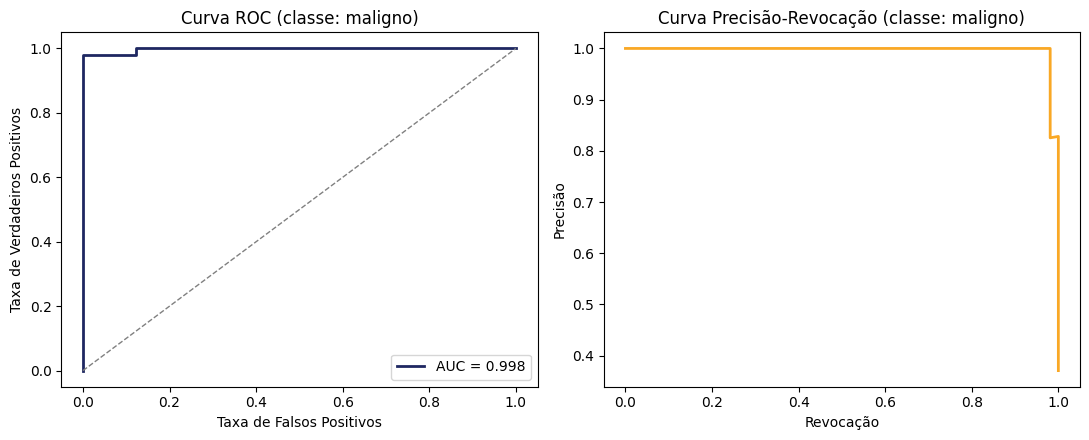

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(1 - y_test, 1 - y_proba)
axes[0].plot(fpr, tpr, color="#1E2761", linewidth=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
axes[0].set_xlabel("Taxa de Falsos Positivos")
axes[0].set_ylabel("Taxa de Verdadeiros Positivos")
axes[0].set_title("Curva ROC (classe: maligno)")
axes[0].legend()

prec_curve, rec_curve, _ = precision_recall_curve(1 - y_test, 1 - y_proba)
axes[1].plot(rec_curve, prec_curve, color="#F9A825", linewidth=2)
axes[1].set_xlabel("Revocação")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precisão-Revocação (classe: maligno)")

plt.tight_layout()
plt.show()
